In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

measurement_folder = Path("Data/irradiation_measurements")
mak_measurement = measurement_folder / "MAK_physics_dept/cleaned"
ministry_energy_measurement = measurement_folder / "ministry_energy_ug/cleaned"
soroti_measurement = ministry_energy_measurement / "Soroti"
wadelai_measurement = ministry_energy_measurement / "Wadelai"
CBE_measurement = measurement_folder / "CBE_Data"

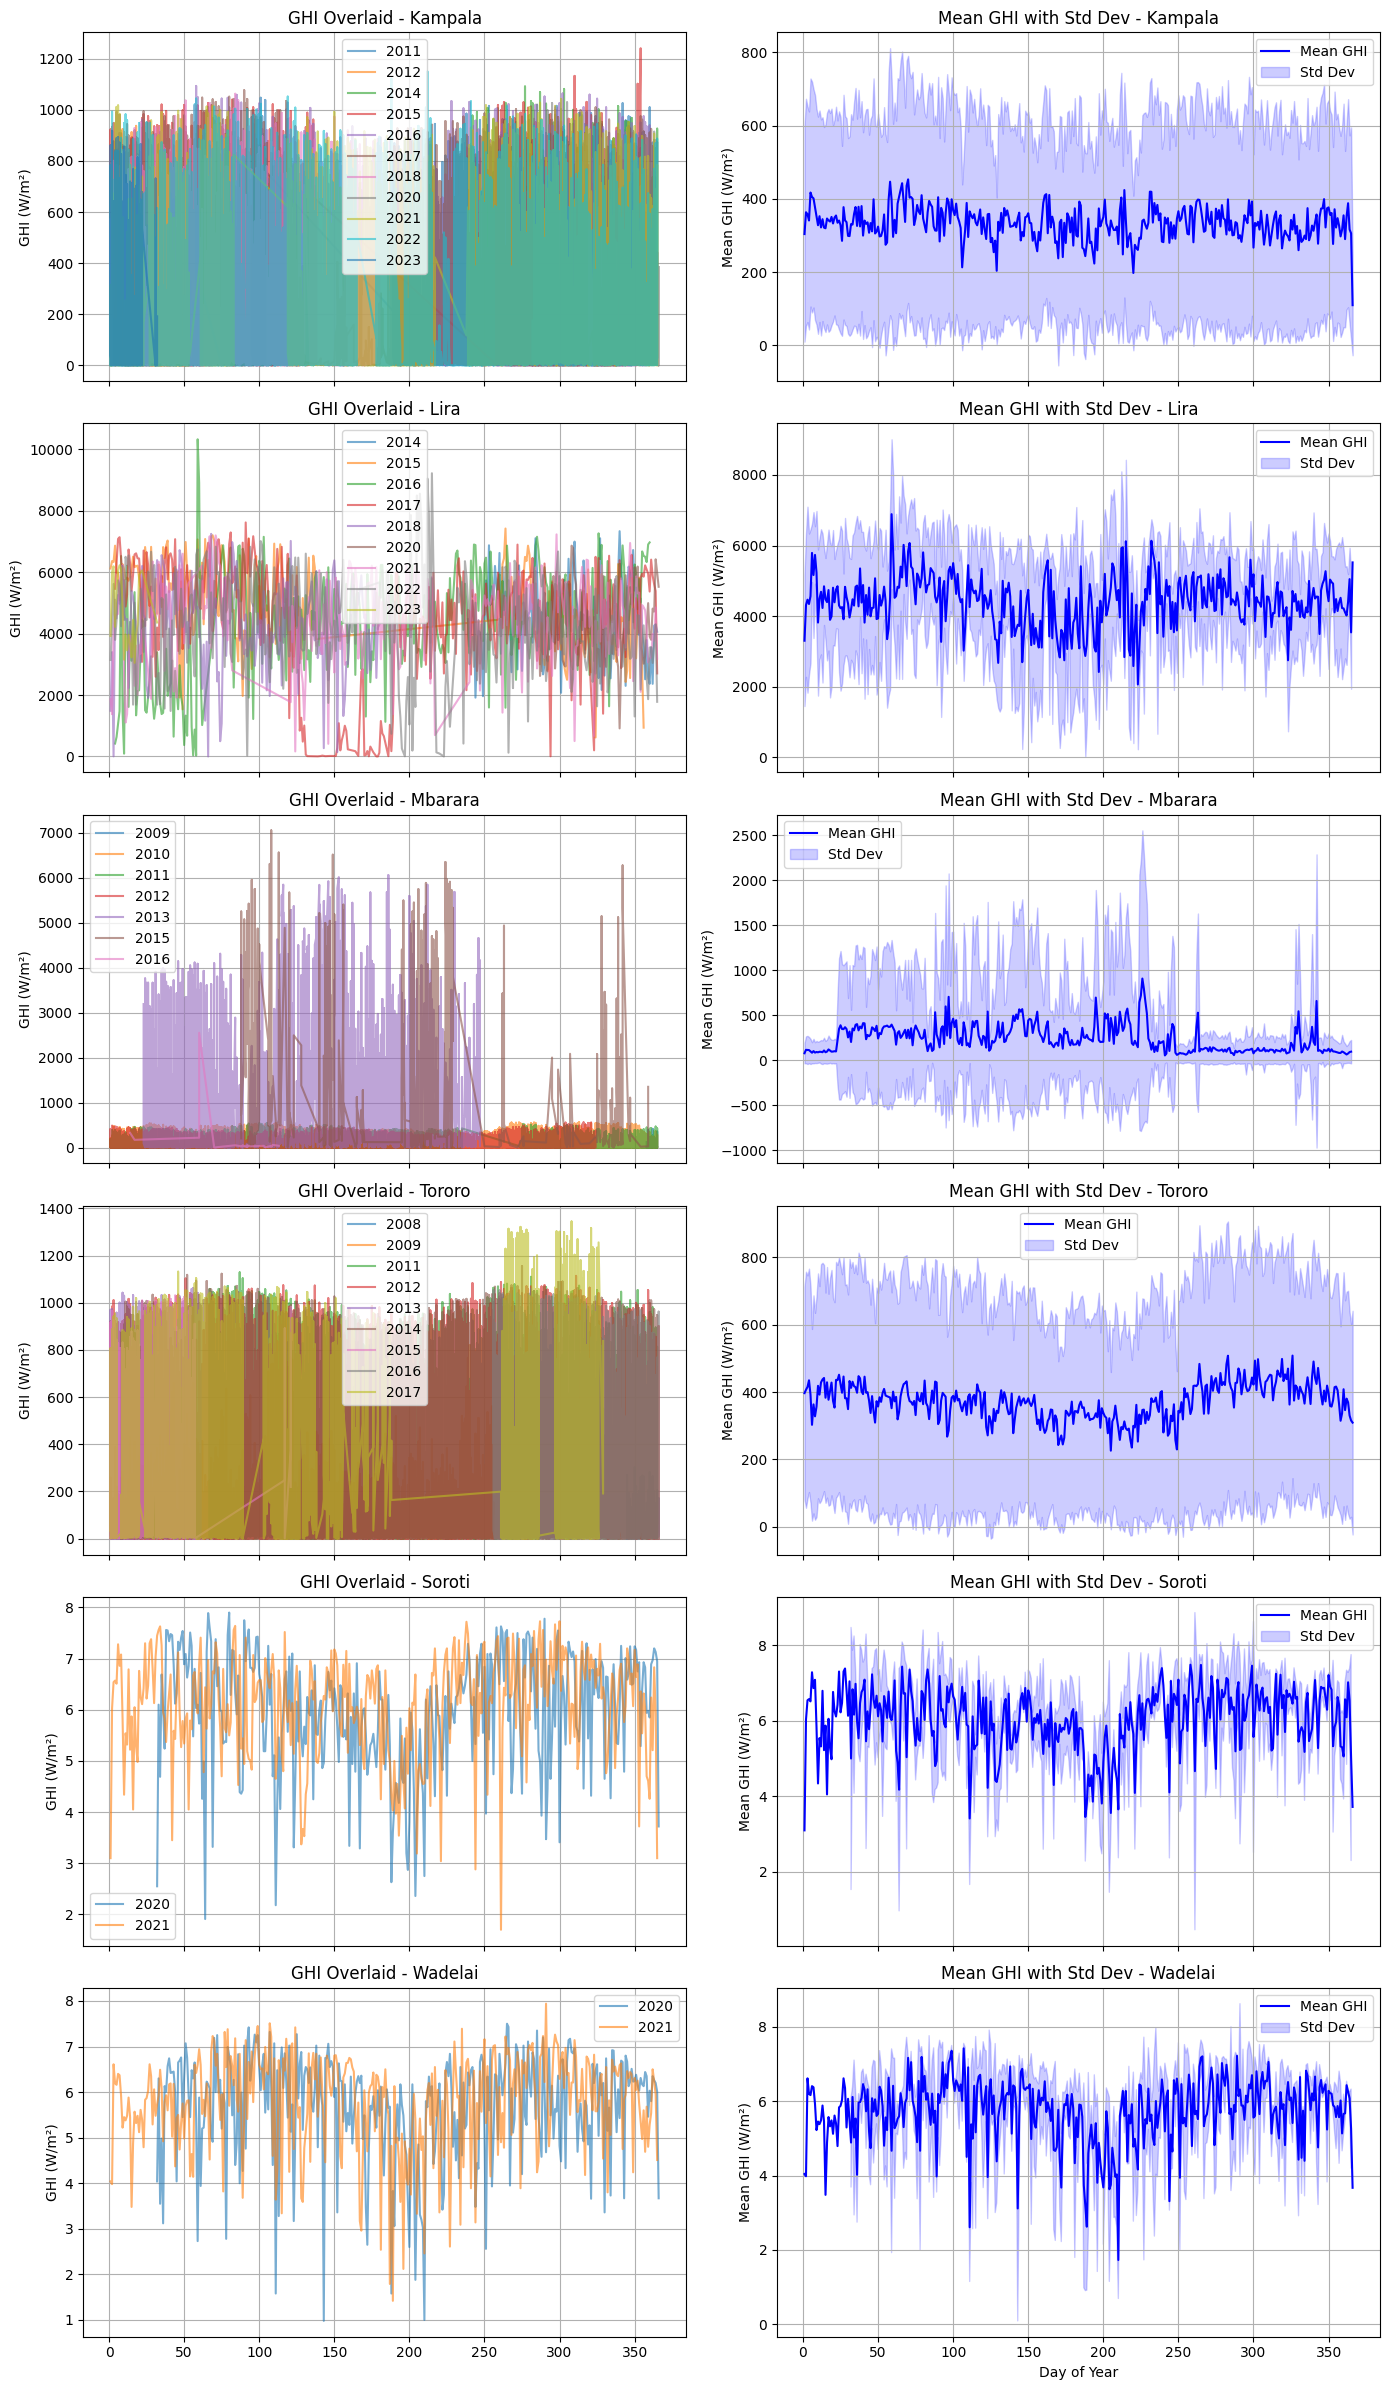

In [7]:
# Define file paths
file_paths = {
    "Kampala": [mak_measurement / "kampala_data.csv"],
    "Lira": [mak_measurement / "lira_data.csv"],
    "Mbarara": [mak_measurement / "mbarara_data.csv"],
    "Tororo": [mak_measurement / "tororo_data.csv"],
    "Soroti": [soroti_measurement / "Soroti_2020.csv", soroti_measurement / "Soroti_2021.csv"],
    "Wadelai": [wadelai_measurement / "Wadelai_2020.csv", wadelai_measurement / "Wadelai_2021.csv"]
}

# Function to read and normalize the CSV files
def read_and_normalize_csv(file_paths, location):
    dataframes = []
    for file_path in file_paths:
        df = pd.read_csv(file_path, index_col=False)

        # Standardize column names
        df.columns = [col.strip().lower() for col in df.columns]

        # Identify datetime column
        if "datetime" in df.columns:
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        elif "day" in df.columns:
            df["datetime"] = pd.to_datetime(df["day"], errors="coerce")
        else:
            print(f"Warning: No recognized datetime column in {file_path.name}")
            continue

        # Extract GHI column
        if "ghi (w/m2)" in df.columns:
            df = df[["datetime", "ghi (w/m2)"]]
            df.rename(columns={"ghi (w/m2)": "ghi"}, inplace=True)
        elif "param_3" in df.columns:  # Assuming Param_3 represents GHI in Mbarara data
            df = df[["datetime", "param_3"]]
            df.rename(columns={"param_3": "ghi"}, inplace=True)
        elif "ghi_1 (kwh/m2/day)" in df.columns:
            df = df[["datetime", "ghi_1 (kwh/m2/day)"]]
            df.rename(columns={"ghi_1 (kwh/m2/day)": "ghi"}, inplace=True)
        else:
            print(f"Warning: No GHI column found in {file_path.name}")
            continue

        df["location"] = location
        df.dropna(inplace=True)  # Remove any rows with missing values
        df = df[df["ghi"] > 0]  # Remove zero values as they indicate missing data
        dataframes.append(df)

    return pd.concat(dataframes, ignore_index=True) if dataframes else None

# Read all dataframes
dataframes = [read_and_normalize_csv(file_paths[loc], loc) for loc in file_paths]
dataframes = [df for df in dataframes if df is not None]  # Filter out None entries

# Combine all data
df_all = pd.concat(dataframes, ignore_index=True)
df_all["datetime"] = pd.to_datetime(df_all["datetime"], errors="coerce")  # Ensure datetime format
df_all.dropna(subset=["datetime"], inplace=True)

# Extract year, month, day, and hour
df_all["year"] = df_all["datetime"].dt.year
df_all["day_of_year"] = df_all["datetime"].dt.dayofyear

# Compute mean and std GHI across years
df_stats = df_all.groupby(["location", "day_of_year"]).agg(
    ghi_mean=("ghi", "mean"),
    ghi_std=("ghi", "std")
).reset_index()

# Create subplots
locations = df_all["location"].unique()
fig, axes = plt.subplots(len(locations), 2, figsize=(14, 4 * len(locations)), sharex=True)

for i, location in enumerate(locations):
    df_loc = df_all[df_all["location"] == location]
    df_stats_loc = df_stats[df_stats["location"] == location]

    # First column: Overlay all GHI, normalized to day of year
    for year in df_loc["year"].unique():
        df_year = df_loc[df_loc["year"] == year]
        axes[i, 0].plot(df_year["day_of_year"], df_year["ghi"], label=f"{year}", alpha=0.6)

    axes[i, 0].set_ylabel("GHI (W/m²)")
    axes[i, 0].set_title(f"GHI Overlaid - {location}")
    axes[i, 0].grid()
    axes[i, 0].legend()

    # Second column: Mean GHI with Std Dev
    axes[i, 1].plot(df_stats_loc["day_of_year"], df_stats_loc["ghi_mean"], label="Mean GHI", color="blue")
    axes[i, 1].fill_between(df_stats_loc["day_of_year"],
                             df_stats_loc["ghi_mean"] - df_stats_loc["ghi_std"],
                             df_stats_loc["ghi_mean"] + df_stats_loc["ghi_std"],
                             color="blue", alpha=0.2, label="Std Dev")

    axes[i, 1].set_ylabel("Mean GHI (W/m²)")
    axes[i, 1].set_title(f"Mean GHI with Std Dev - {location}")
    axes[i, 1].grid()
    axes[i, 1].legend()

plt.xlabel("Day of Year")
plt.tight_layout()
plt.show()
